In [1]:
import pandas as pd    
import numpy as np    
import os            
import warnings
warnings.filterwarnings('ignore') 

In [2]:
DATA_DIR = r"C:\Users\omen\Downloads\archive"

In [4]:
def compute_descriptive_stats(series, label):
    clean = series.dropna()
    
    if len(clean) < 2:
        return {f'{label}_mean': np.nan, f'{label}_median': np.nan,
                f'{label}_std': np.nan, f'{label}_skew': np.nan,
                f'{label}_kurtosis': np.nan, f'{label}_count': 0}
        
    return {
        f'{label}_mean': clean.mean(),
        f'{label}_median': clean.median(),
        f'{label}_std':      clean.std(),
        f'{label}_skew':     clean.skew(), 
        f'{label}_kurtosis': clean.kurtosis(),     
        f'{label}_count':    len(clean),
    }


In [5]:
per_day_stats = []

pooled_prices = []
pooled_ret_1s = []
pooled_ret_1m = []
pooled_ret_5m = []

In [6]:
for day in range(1, 86):
    filepath = f"{DATA_DIR}/day{day}.csv"
    if not os.path.exists(filepath):
        continue
    
    df = pd.read_csv(filepath)
    price = df['Price']
    ret_1s = price.pct_change(1)
    ret_1m = price.pct_change(60)
    ret_5m = price.pct_change(300)
    
    row = {'day': day}
    row.update(compute_descriptive_stats(price,  'price'))
    row.update(compute_descriptive_stats(ret_1s, 'ret_1s'))
    row.update(compute_descriptive_stats(ret_1m, 'ret_1m'))
    row.update(compute_descriptive_stats(ret_5m, 'ret_5m'))
    per_day_stats.append(row)
    
    pooled_prices.append(price.dropna())
    pooled_ret_1s.append(ret_1s.dropna())
    pooled_ret_1m.append(ret_1m.dropna())
    pooled_ret_5m.append(ret_5m.dropna())
    
per_day_df = pd.DataFrame(per_day_stats)
pooled_prices_all = pd.concat(pooled_prices, ignore_index=True)
pooled_ret_1s_all = pd.concat(pooled_ret_1s, ignore_index=True)
pooled_ret_1m_all = pd.concat(pooled_ret_1m, ignore_index=True)
pooled_ret_5m_all = pd.concat(pooled_ret_5m, ignore_index=True)

pooled_summary = pd.DataFrame([
    compute_descriptive_stats(pooled_prices_all, 'price'),
    compute_descriptive_stats(pooled_ret_1s_all, 'ret_1s'),
    compute_descriptive_stats(pooled_ret_1m_all, 'ret_1m'),
    compute_descriptive_stats(pooled_ret_5m_all, 'ret_5m'),
])

per_day_df.to_csv("per_day_descriptive_stats.csv", index=False)
pooled_summary.to_csv("pooled_descriptive_stats.csv", index=False)


In [7]:
################### AUTO CORRELATION FUNCTTION #######################
lags = range(1, 61)
acf_per_day = []

In [8]:
for day in range(1, 86):
    filepath = f"{DATA_DIR}/day{day}.csv"
    if not os.path.exists(filepath):
        continue
    
    df = pd.read_csv(filepath)
    ret = df['Price'].pct_change(1).dropna()
    day_acf = {}
    for lag in lags:
        day_acf[f'lag_{lag}'] = ret.autocorr(lag=lag)
    acf_per_day.append(day_acf)


In [9]:
acf_df = pd.DataFrame(acf_per_day)
avg_acf = acf_df.mean()

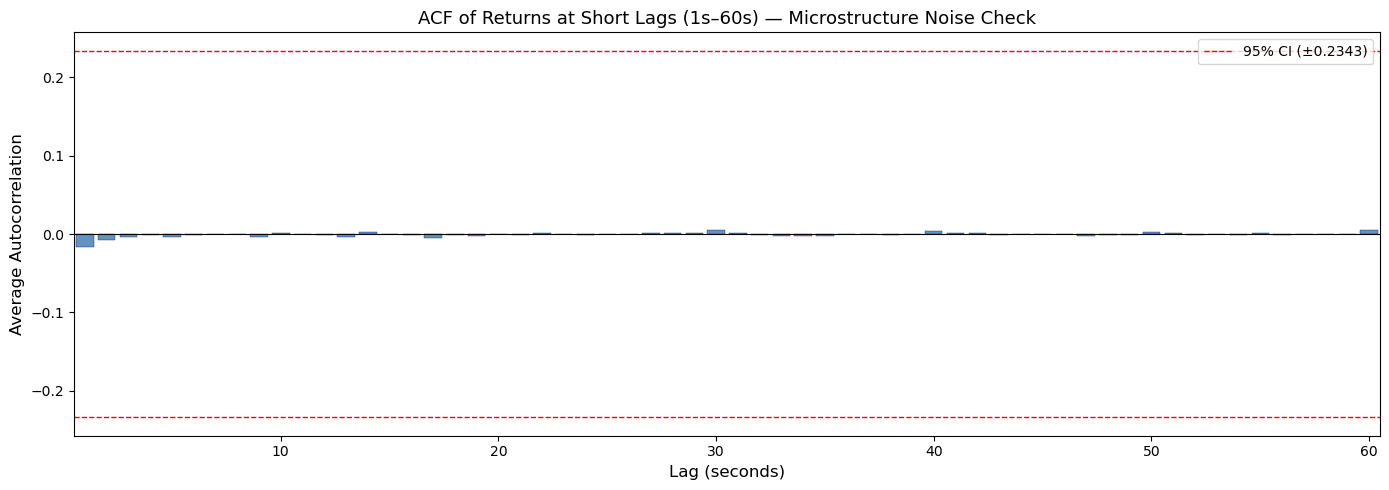

MICROSTRUCTURE NOISE ANALYSIS
Lag-1 autocorrelation (avg across days): -0.017081
95% confidence bound:                    ±0.234265
Number of lags with significant ACF:     0 / 60
------------------------------------------------------------
CONCLUSION: Little to no evidence of microstructure noise.
  → Lag-1 autocorrelation is within the confidence band.


In [11]:
################## TO ADD OBSERVATIONS OF AUTO CORRELATION FUNCTION IN REPORT #############################
# Average number of observations per day for confidence interval
avg_n = acf_df.count().mean()
conf_bound = 1.96 / np.sqrt(avg_n)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
lag_vals = list(range(1, 61))
acf_vals = [avg_acf[f'lag_{l}'] for l in lag_vals]

ax.bar(lag_vals, acf_vals, color='steelblue', alpha=0.85, edgecolor='navy', linewidth=0.3)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(conf_bound, color='red', linestyle='--', linewidth=1, label=f'95% CI (±{conf_bound:.4f})')
ax.axhline(-conf_bound, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Lag (seconds)', fontsize=12)
ax.set_ylabel('Average Autocorrelation', fontsize=12)
ax.set_title('ACF of Returns at Short Lags (1s–60s) — Microstructure Noise Check', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0.5, 60.5)
plt.tight_layout()
plt.show()

# --- Print interpretation ---
lag1_acf = avg_acf['lag_1']
significant_lags = [l for l in lag_vals if abs(avg_acf[f'lag_{l}']) > conf_bound]

print("=" * 60)
print("MICROSTRUCTURE NOISE ANALYSIS")
print("=" * 60)
print(f"Lag-1 autocorrelation (avg across days): {lag1_acf:.6f}")
print(f"95% confidence bound:                    ±{conf_bound:.6f}")
print(f"Number of lags with significant ACF:     {len(significant_lags)} / 60")
if significant_lags:
    print(f"Significant at lags:                     {significant_lags}")
print("-" * 60)

if lag1_acf < -conf_bound:
    print("CONCLUSION: Strong evidence of microstructure noise.")
    print("  → Significant NEGATIVE lag-1 autocorrelation detected,")
    print("    consistent with bid-ask bounce effect.")
elif lag1_acf > conf_bound:
    print("CONCLUSION: Evidence of microstructure noise.")
    print("  → Significant POSITIVE lag-1 autocorrelation detected,")
    print("    suggesting short-term serial dependence (possibly due")
    print("    to stale quotes or trade clustering).")
else:
    print("CONCLUSION: Little to no evidence of microstructure noise.")
    print("  → Lag-1 autocorrelation is within the confidence band.")

if len(significant_lags) > 5:
    print("  → Multiple lags show significant autocorrelation,")
    print("    reinforcing the presence of microstructure effects.")
print("=" * 60)


INTRA DAY SEASONALITY

In [16]:
import pandas as pd
import numpy as np
import os
DATA_DIR = r"C:\Users\omen\Downloads\archive"

per_day_bins = []

for day in range(1, 86):
    filepath = f"{DATA_DIR}/day{day}.csv"
    if not os.path.exists(filepath):
        continue

    df = pd.read_csv(filepath)
    df['abs_ret'] = df['Price'].pct_change(1).abs()

    df['seconds'] = df['Time'].apply(
        lambda t: int(t.split(':')[0])*3600 + int(t.split(':')[1])*60 + int(t.split(':')[2])
        if isinstance(t, str) and ':' in str(t) else np.nan
    )
    df = df.dropna(subset=['seconds', 'abs_ret'])
    df['bin_seconds'] = (df['seconds'] // 300) * 300

    day_grouped = df.groupby('bin_seconds').agg(
        day_mean_vol=('abs_ret', 'mean')
    ).reset_index()
    day_grouped['day'] = day
    per_day_bins.append(day_grouped)

all_bins = pd.concat(per_day_bins, ignore_index=True)

result = all_bins.groupby('bin_seconds').agg(
    day_count=('day', 'nunique'),
    mean_realized_1s_volatility=('day_mean_vol', 'mean'),
    std_across_days=('day_mean_vol', 'std')
).reset_index()

result.to_csv("volatility_seasonality.csv", index=False)


Pattern detected: U-SHAPE
Open volatility:   3.23e-05 (1.50x midday)
Midday volatility: 2.15e-05
Close volatility:  2.52e-05 (1.17x midday)
Peak at:   00:00 (4.62e-05)
Trough at: 02:45 (2.03e-05)


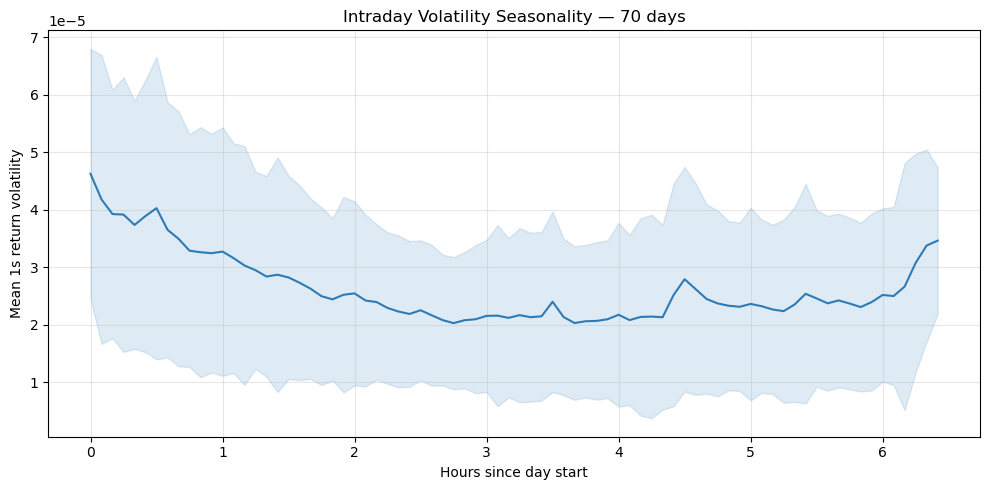

In [19]:
############### TO ADD OBSERVATIONS OF INTRADAY SEASONALITY IN REPORT ########################
import pandas as pd
import matplotlib.pyplot as plt

s = pd.read_csv("volatility_seasonality.csv")

hours = s['bin_seconds'] / 3600
vol = s['mean_realized_1s_volatility']
n = len(s)

# --- U-Shape Test ---
first_third  = vol.iloc[:n//3].mean()
middle_third = vol.iloc[n//3:2*n//3].mean()
last_third   = vol.iloc[2*n//3:].mean()

open_ratio  = first_third / middle_third
close_ratio = last_third / middle_third

if first_third > middle_third and last_third > middle_third:
    shape = "U-SHAPE"
elif first_third > middle_third:
    shape = "L-SHAPE / J-SHAPE"
elif last_third > middle_third:
    shape = "REVERSE-J"
else:
    shape = "NO PATTERN"

# --- Peak and Trough ---
peak  = s.loc[vol.idxmax()]
trough = s.loc[vol.idxmin()]

def sec_to_time(sec):
    return f"{int(sec//3600):02d}:{int((sec%3600)//60):02d}"

# --- Print Results ---
print(f"Pattern detected: {shape}")
print(f"Open volatility:   {first_third:.2e} ({open_ratio:.2f}x midday)")
print(f"Midday volatility: {middle_third:.2e}")
print(f"Close volatility:  {last_third:.2e} ({close_ratio:.2f}x midday)")
print(f"Peak at:   {sec_to_time(peak['bin_seconds'])} ({peak['mean_realized_1s_volatility']:.2e})")
print(f"Trough at: {sec_to_time(trough['bin_seconds'])} ({trough['mean_realized_1s_volatility']:.2e})")

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hours, vol, color='#2c7bb6', linewidth=1.5)
ax.fill_between(hours, vol - s['std_across_days'], vol + s['std_across_days'],
                alpha=0.15, color='#2c7bb6')
ax.set_title(f"Intraday Volatility Seasonality — {s['day_count'].iloc[0]} days")
ax.set_xlabel("Hours since day start")
ax.set_ylabel("Mean 1s return volatility")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("volatility_seasonality_plot.png", dpi=150)
plt.show()
